Module 2 ✅ Signal Preprocessing

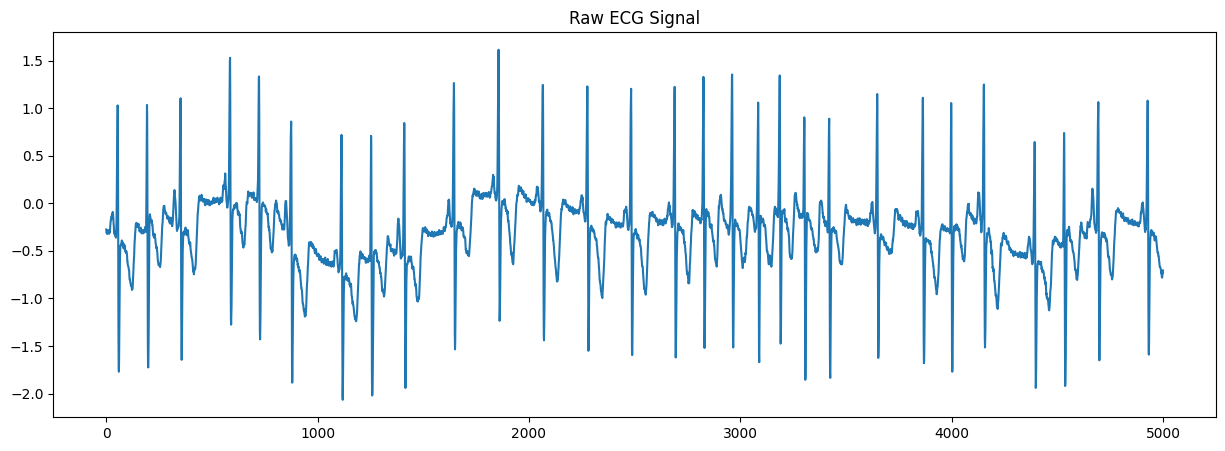

In [1]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord(
    r"C:\Users\hrkap\OneDrive\Desktop\VitaTwin-AI project\datasets\raw\afdb\04015"
)

signal = record.p_signal[:,0]

plt.figure(figsize=(15,5))
plt.plot(signal[:5000])
plt.title("Raw ECG Signal")
plt.show()

In [3]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

normalized_signal = scaler.fit_transform(
    signal.reshape(-1,1)
)

normalized_signal = normalized_signal.flatten()

print(normalized_signal[:10])

[0.4729123  0.47171506 0.47081712 0.47051781 0.47141574 0.4702185
 0.47141574 0.47141574 0.47201437 0.47261299]


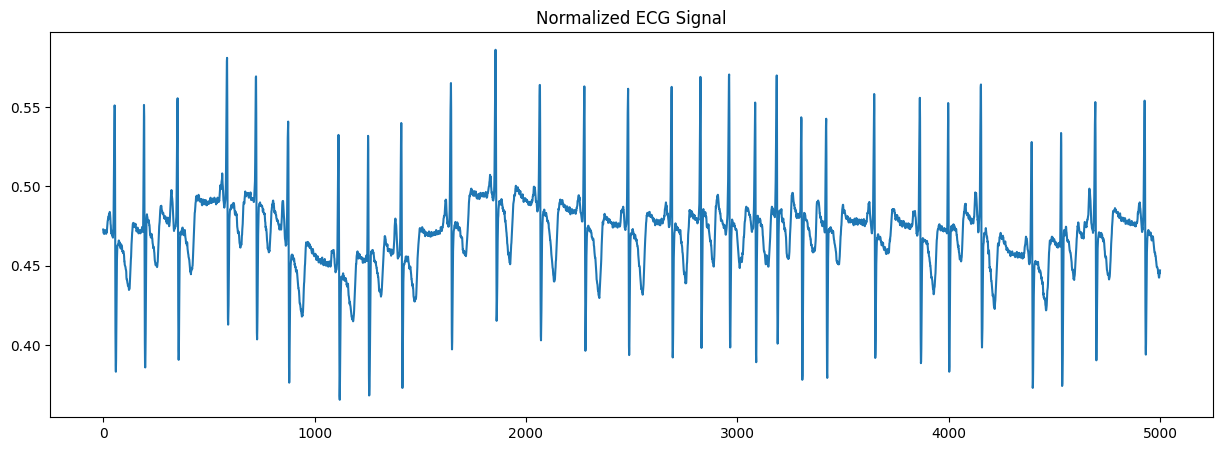

In [4]:
plt.figure(figsize=(15,5))
plt.plot(normalized_signal[:5000])
plt.title("Normalized ECG Signal")
plt.show()

In [5]:
from scipy.signal import butter, filtfilt

def butter_lowpass_filter(data, cutoff=40, fs=250, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order,
                  normal_cutoff,
                  btype='low',
                  analog=False)

    return filtfilt(b, a, data)

filtered_signal = butter_lowpass_filter(signal)

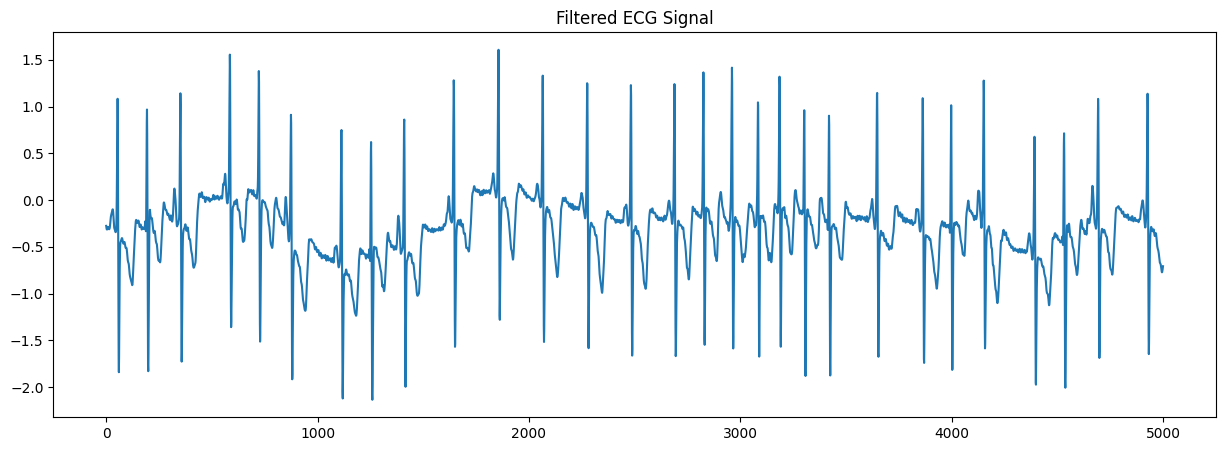

In [6]:
plt.figure(figsize=(15,5))
plt.plot(filtered_signal[:5000])
plt.title("Filtered ECG Signal")
plt.show()

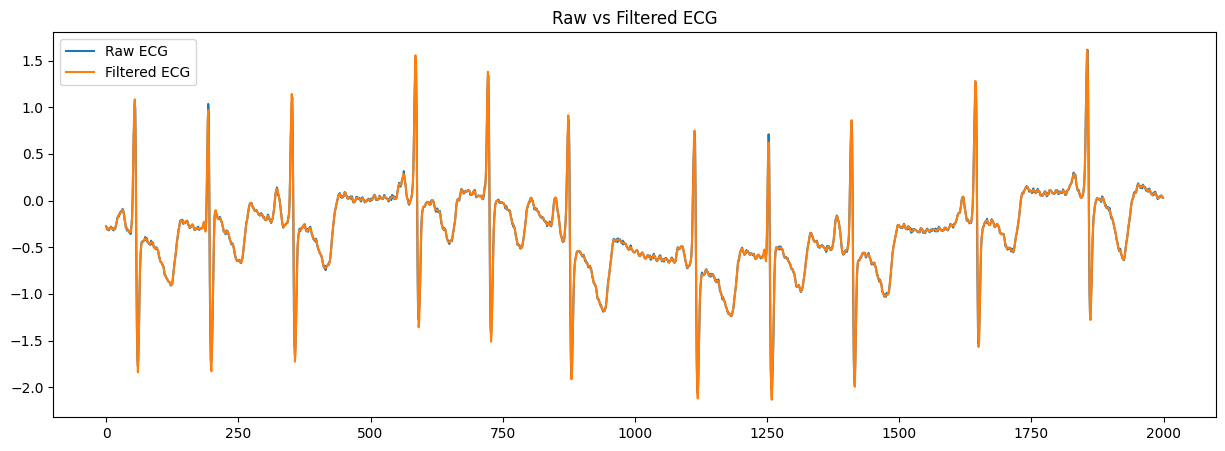

In [7]:
plt.figure(figsize=(15,5))

plt.plot(signal[:2000], label="Raw ECG")
plt.plot(filtered_signal[:2000], label="Filtered ECG")

plt.legend()
plt.title("Raw vs Filtered ECG")
plt.show()